<a href="https://colab.research.google.com/github/gautami06647/AI-ML-internship-assignments/blob/supervised-learning/random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
np.random.seed(42)

data = {
    'Study_Hours': np.random.randint(1, 10, 200),
    'Attendance': np.random.randint(50, 100, 200),
    'Sleep_Hours': np.random.randint(4, 9, 200),
    'Previous_Score': np.random.randint(40, 100, 200),
    'Result': np.random.choice([0, 1], 200)  # 0 = Fail, 1 = Pass
}

df = pd.DataFrame(data)
df.head()

,Study_Hours,Attendance,Sleep_Hours,Previous_Score,Result
0,7,50,4,80,0
1,4,60,7,78,0
2,8,77,8,40,0
3,5,74,4,42,1
4,7,99,5,52,1


In [ ]:
X = df.drop('Result', axis=1)
y = df['Result']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.44


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("confusion_matrix: ")
print(cm)

confusion_matrix: 
[[13 11]
 [17  9]]


In [ ]:
  print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.43      0.54      0.48        24
           1       0.45      0.35      0.39        26

    accuracy                           0.44        50
   macro avg       0.44      0.44      0.44        50
weighted avg       0.44      0.44      0.43        50



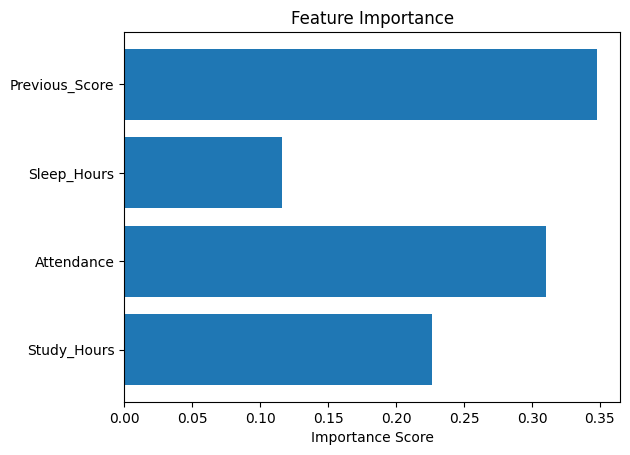

In [ ]:
importance = rf.feature_importances_

plt.figure()
plt.barh(X.columns, importance)
plt.xlabel("Importance Score")
plt.title("Feature Importance")
plt.show()

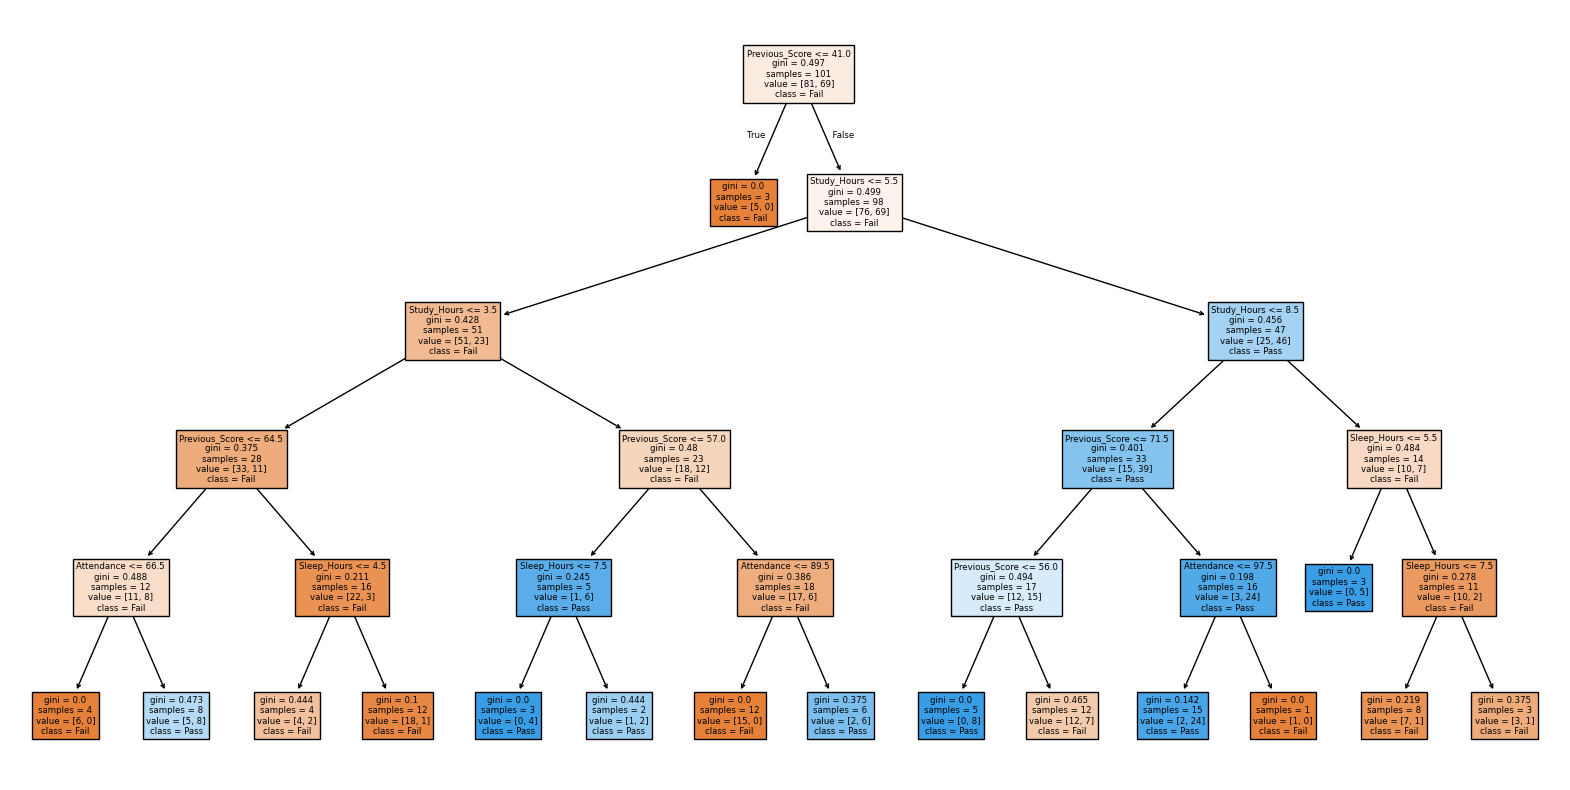

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True
)
plt.show()